In [1]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.2.0


# OFDM Radar: Orthogonal Frequency Division Multiplexing

**OFDM (Orthogonal Frequency Division Multiplexing) radar** transmits many orthogonal subcarriers simultaneously, each modulated with a data symbol (e.g. QPSK), instead of sweeping frequency (FMCW) or phase-coding a single carrier (PMCW). The technique is borrowed directly from OFDM communication systems (Wi-Fi, LTE/5G) and is increasingly used for joint radar-communication systems.

**Transmitted signal** (one OFDM symbol, $N$ subcarriers spaced by $\Delta f$):

$$s(t) = \sum_{k=0}^{N-1} X_k \, e^{j2\pi k \Delta f t}, \qquad 0 \le t < T_{sym} = \frac{1}{\Delta f}$$

where $X_k$ is the complex data symbol on subcarrier $k$. This is exactly an **IDFT**, so $s(t)$ can be efficiently generated (and, at the receiver, reversed) with an IFFT/FFT pair.

**Range processing** — divide the received per-subcarrier spectrum by the known transmitted data to strip the communication content, leaving only the channel's frequency response, then IFFT back to the time domain:

$$Y_k = X_k \cdot H_k, \qquad H_k = \frac{Y_k}{X_k} = A \, e^{-j2\pi k \Delta f \tau} \;\;\Longrightarrow\;\; \text{IFFT}_k\{H_k\} \text{ peaks at } \tau = \frac{2R}{c}$$

$$\Delta R = \frac{c}{2 N \Delta f}, \qquad R_{max} = \frac{c}{2\Delta f}$$

**Velocity** is extracted the same way as FMCW/PMCW — an FFT across successive OFDM symbols (slow-time) at a fixed range bin:

$$f_d = \frac{2v_r f_c}{c}, \qquad v_{max} = \frac{c}{2 f_c \cdot PRP}$$

### FMCW vs. PMCW vs. OFDM

| Feature | FMCW | PMCW | OFDM |
|---------|------|------|------|
| Modulation | Frequency chirp | Phase code (BPSK) | Multi-carrier phase/amplitude (QPSK/QAM) |
| Range | Beat frequency | Code correlation | Subcarrier phase ramp (per-symbol IFFT) |
| Waveform generation | Analog sweep | Digital chip sequence | Digital IFFT (communications-style) |
| Data payload | None | Limited (code selection) | Full — inherently a comms waveform |
| Interference | Sensitive | Orthogonal code rejection | Subcarrier/coding based rejection |
| Sampling rate | ~MHz (beat freq) | ~chip rate | ~occupied bandwidth |

### This Example

Uses `RadarSimPy` to simulate a single-channel OFDM radar:

- **Carrier**: 24.125 GHz, 256 subcarriers spaced 390.625 kHz apart → 100 MHz occupied bandwidth
- **Data**: Random QPSK symbols on every subcarrier, generated once via IFFT and repeated every OFDM symbol
- **256 OFDM symbols** transmitted back-to-back for Doppler processing
- **3 targets**: ranges/velocities in the same spirit as the FMCW example (far/slow, mid/fast, near/moderate), with RCS values chosen to balance the link budget across ranges
- **Processing**: per-symbol frequency-domain data removal + IFFT (range) → windowed FFT across symbols (Doppler)

## Radar System Configuration

### Import Required Modules

In [51]:
# Import necessary modules for radar simulation
import numpy as np
from radarsimpy import Radar, Transmitter, Receiver
from radarsimpy.simulator import sim_radar
from scipy import signal
import plotly.graph_objs as go
from IPython.display import Image, display

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

### OFDM Waveform Parameters

The subcarrier spacing `df` and subcarrier count `N_sc` set the occupied bandwidth (and therefore range resolution), while the symbol duration `T_sym = 1 / df` is the inverse of the subcarrier spacing — a fundamental OFDM property.

| Parameter | Value | Notes |
|-----------|-------|-------|
| Carrier frequency `fc` | 24.125 GHz | Constant — no frequency sweep |
| Subcarriers `N_sc` | 256 | |
| Subcarrier spacing `df` | 390.625 kHz | |
| Occupied bandwidth | 100 MHz | $N_{sc} \times \Delta f$, same as the FMCW example → 1.5 m range resolution |
| Symbol duration `T_sym` | 2.56 μs | $1/\Delta f$, no cyclic prefix (kept simple for this demo) |
| Sample rate `fs` | 100 MHz | Matches occupied bandwidth (one sample per subcarrier slot) |
| OFDM symbols (pulses) | 256 | For Doppler processing |
| PRP | 2.56 μs | Back-to-back symbols, no gap |

In [3]:
# OFDM waveform design parameters
fc = 24.125e9  # Carrier frequency: 24.125 GHz
N_sc = 256  # Number of subcarriers
df = 390.625e3  # Subcarrier spacing: 390.625 kHz
bandwidth = N_sc * df  # Occupied bandwidth: 100 MHz
T_sym = 1 / df  # OFDM symbol duration: 2.56 μs (no cyclic prefix)
Ts = T_sym / N_sc  # Sample interval: 10 ns
fs = 1 / Ts  # Sample rate: 100 MHz (matches bandwidth)
n_pulses = 256  # Number of OFDM symbols (slow-time / Doppler dimension)

### Generate the OFDM Baseband Symbol

Assign a random **QPSK** data symbol to every subcarrier, then build the time-domain baseband waveform with an **IFFT** — exactly as an OFDM transmitter would. The same symbol is reused for every pulse; `RadarSimPy`'s per-channel waveform modulation (`mod_t`/`amp`/`phs`) applies this arbitrary complex baseband waveform on top of the constant 24.125 GHz carrier for each OFDM symbol.

In [17]:
# Generate random QPSK data symbols for all subcarriers (reproducible)
np.random.seed(1)
bits_i = np.random.randint(0, 2, N_sc)
bits_q = np.random.randint(0, 2, N_sc)
data_symbols = (2 * bits_i - 1 + 1j * (2 * bits_q - 1)) / np.sqrt(2)  # Unit-power QPSK

# Build the OFDM baseband time-domain symbol via IFFT (subcarriers -> time samples)
ofdm_symbol = np.fft.ifft(data_symbols)
# Normalize to unit average power (RMS = 1), matching FMCW/PMCW's constant-envelope
# convention. Individual samples can still exceed 1 -- this is exactly OFDM's
# peak-to-average power ratio (PAPR).
ofdm_symbol = ofdm_symbol / np.sqrt(np.mean(np.abs(ofdm_symbol) ** 2))

# Waveform modulation arrays for the transmitter channel
mod_t = np.arange(N_sc) * Ts  # Time stamps: 0, Ts, 2*Ts, ... (256 samples)
amp = np.abs(ofdm_symbol)  # Relative amplitude (envelope)
phs = np.angle(ofdm_symbol, deg=True)  # Phase in degrees

### Visualize the QPSK Constellation

Display the random data symbols assigned to the 256 subcarriers before the IFFT.

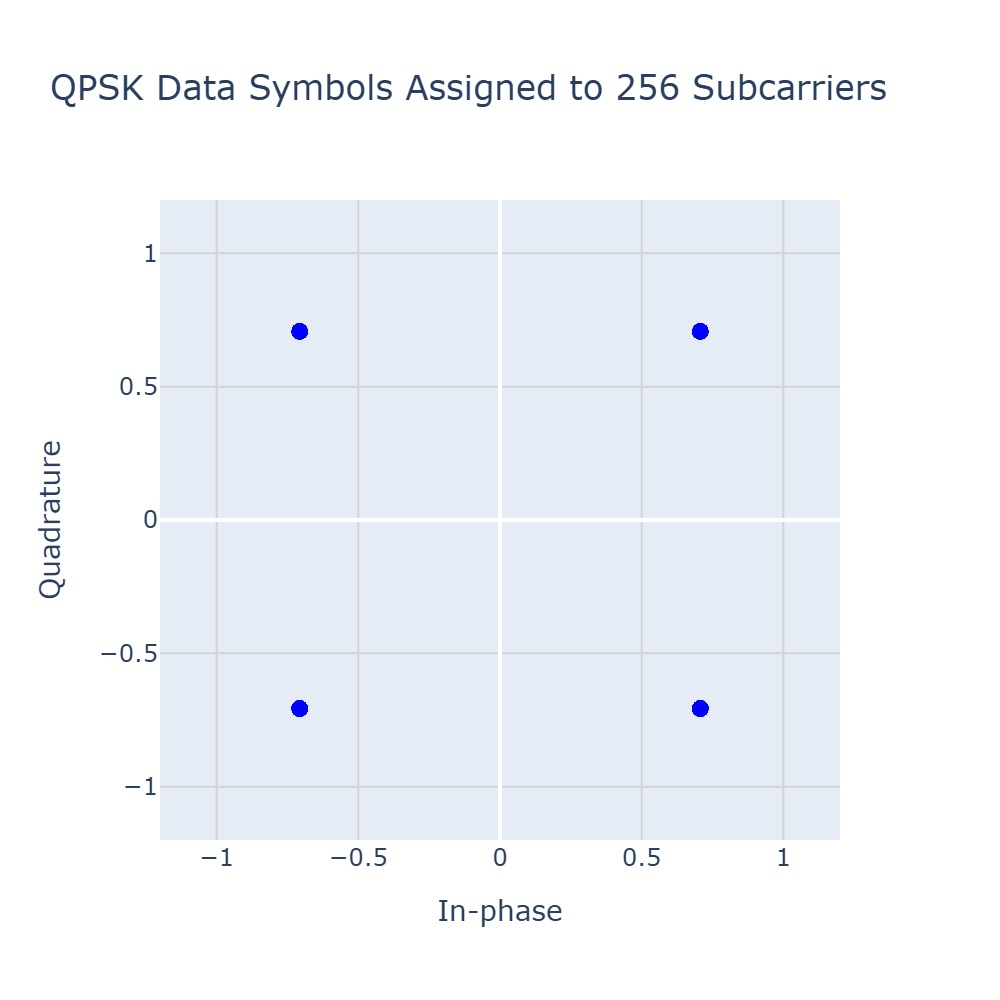

In [5]:
# Create figure for QPSK constellation
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=np.real(data_symbols),
        y=np.imag(data_symbols),
        mode="markers",
        marker=dict(size=8, color="blue"),
        name="Subcarrier data",
    )
)

fig.update_layout(
    title="QPSK Data Symbols Assigned to 256 Subcarriers",
    yaxis=dict(title="Quadrature", range=[-1.2, 1.2], gridcolor="lightgray"),
    xaxis=dict(title="In-phase", range=[-1.2, 1.2], gridcolor="lightgray"),
    height=500,
    width=500,
)

show(fig)

### Visualize the Time-Domain OFDM Symbol

The IFFT of many independent subcarriers produces a noise-like envelope with a high peak-to-average power ratio (PAPR) — a well-known OFDM characteristic. The waveform is normalized to unit **average** power, so individual samples peak well above 1.

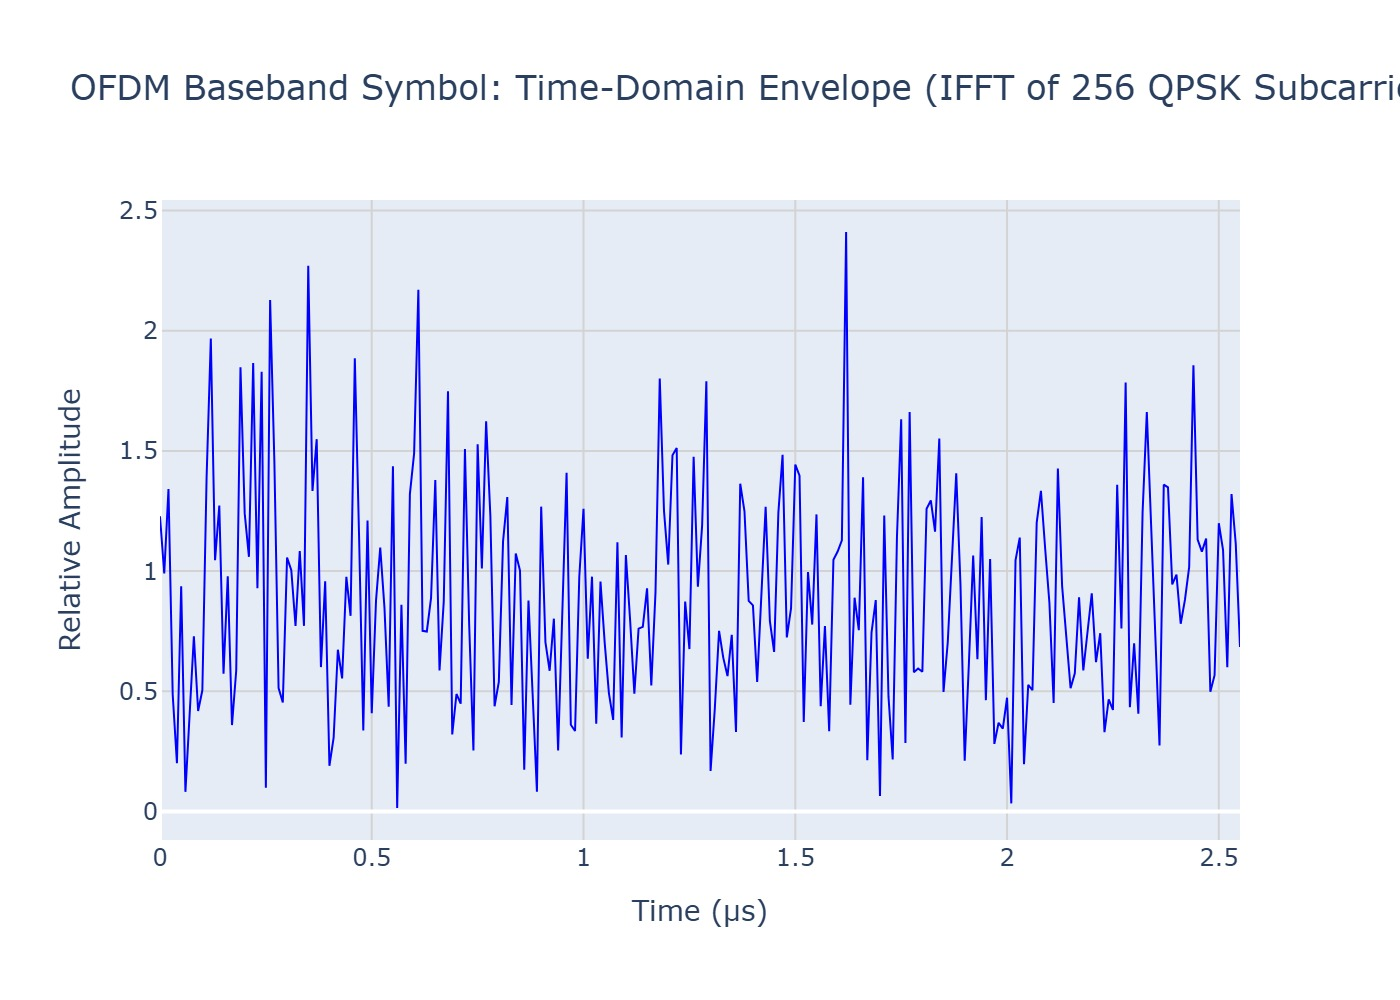

In [18]:
# Create figure for the time-domain OFDM symbol envelope
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=mod_t * 1e6,
        y=amp,
        name="Envelope (amplitude)",
        line=dict(color="blue", width=1),
    )
)

fig.update_layout(
    title="OFDM Baseband Symbol: Time-Domain Envelope (IFFT of 256 QPSK Subcarriers)",
    yaxis=dict(title="Relative Amplitude", gridcolor="lightgray"),
    xaxis=dict(title="Time (μs)", gridcolor="lightgray"),
    height=500,
)

show(fig)

### Transmitter Configuration

The transmitter uses a **constant carrier** (no chirp) with the OFDM symbol applied as arbitrary waveform modulation (`mod_t`/`amp`/`phs`), repeated identically over 256 pulses (OFDM symbols).

| Parameter | Value | Notes |
|-----------|-------|-------|
| Carrier frequency | 24.125 GHz | Constant |
| Pulse duration | 2.56 μs | One OFDM symbol |
| TX power | 25 dBm | Higher than the FMCW/PMCW examples — needed to offset the much wider 100 MHz noise bandwidth used here |
| Pulses | 256 | One per OFDM symbol |
| PRP | 2.56 μs (default) | Back-to-back symbols |

In [39]:
# Define transmitter channel with OFDM waveform modulation
tx_channel = dict(
    location=(0, 0, 0),  # Antenna position at origin
    mod_t=mod_t,  # OFDM symbol timing (256 samples x 10 ns)
    amp=amp,  # OFDM symbol amplitude envelope
    phs=phs,  # OFDM symbol phase (degrees)
)

# Configure OFDM transmitter
tx = Transmitter(
    f=fc,  # Carrier frequency: 24.125 GHz (constant, no chirp)
    t=T_sym,  # Pulse duration: one OFDM symbol (2.56 μs)
    tx_power=25,  # Transmit power: 25 dBm (offsets the wide 100 MHz noise bandwidth)
    pulses=n_pulses,  # Number of OFDM symbols: 256 (for Doppler processing)
    channels=[tx_channel],  # Transmitter antenna configuration
)

### Receiver Configuration

The sampling rate must match the OFDM occupied bandwidth so the FFT recovers exactly `N_sc` subcarrier bins per symbol.

| Parameter | Value |
|-----------|-------|
| Sampling rate `fs` | 100 MHz |
| Noise figure | 10 dB |
| RF gain | 20 dB |
| Baseband gain | 30 dB |
| Load resistor | 500 Ω |

In [40]:
# Configure OFDM radar receiver
rx = Receiver(
    fs=fs,  # Sampling rate: 100 MHz (matches occupied bandwidth)
    noise_figure=10,  # Noise figure: 10 dB
    rf_gain=20,  # RF gain: 20 dB (LNA)
    baseband_gain=30,  # Baseband gain: 30 dB (total gain: 50 dB)
    load_resistor=500,  # Load resistance: 500 Ω
    channels=[dict(location=(0, 0, 0))],  # Single RX at origin
)

### Create Radar System

Combine transmitter and receiver to form the complete OFDM radar.

In [41]:
# Create complete OFDM radar system
radar = Radar(transmitter=tx, receiver=rx)

## Target Configuration

Three point targets, in the same spirit as the FMCW example (far/slow, mid/fast, near/moderate). Because OFDM's 100 MHz *noise* bandwidth is far wider than FMCW's ~MHz beat-frequency bandwidth, the RCS values here are chosen to keep the received power of all three targets within a similar range, rather than reusing FMCW's exact numbers (which would leave the 200 m target buried under the near target's range sidelobes):

| Target | Location (m) | Speed (m/s) | RCS (dBsm) | Description |
|--------|-------------|-------------|-----------|-------------|
| 1 | (120, 0, 0) | (−5, 0, 0) | 20 | Slow, large, far |
| 2 | (70, 20, 0) | (−50, 0, 0) | 12 | Fast, medium, mid-range |
| 3 | (30, −5, 0) | (−22, 0, 0) | 5 | Moderate, small, near |

OFDM's short symbol duration gives a very high unambiguous velocity ($v_{max} \approx 2.4$ km/s), so none of these targets will alias in Doppler.

In [42]:
# Configure Target 1: Large, slow, far vehicle
target_1 = dict(
    location=(120, 0, 0),  # Position: 120m range
    speed=(-5, 0, 0),  # Velocity: -5 m/s (18 km/h approaching)
    rcs=20,  # Radar cross section: 20 dBsm (100 m² - truck)
    phase=0,  # Initial phase: 0 degrees
)

# Configure Target 2: Medium vehicle, high speed
target_2 = dict(
    location=(70, 20, 0),  # Position: ~73m range, 20m Y-offset
    speed=(-50, 0, 0),  # Velocity: -50 m/s (180 km/h approaching)
    rcs=12,  # Radar cross section: 12 dBsm (15.8 m² - car)
    phase=0,  # Initial phase: 0 degrees
)

# Configure Target 3: Small vehicle, moderate speed, close
target_3 = dict(
    location=(30, -5, 0),  # Position: ~30m range, -5m Y-offset
    speed=(-22, 0, 0),  # Velocity: -22 m/s (79 km/h approaching)
    rcs=5,  # Radar cross section: 5 dBsm (3.16 m² - motorcycle)
    phase=0,  # Initial phase: 0 degrees
)

# Combine targets for simulation
targets = [target_1, target_2, target_3]

## Simulate Baseband Signals

`sim_radar` computes the complex I/Q baseband signal for each OFDM symbol, incorporating propagation delay, Doppler shift, RCS weighting, and thermal noise.

Output shape: `[channels, pulses, samples]` → `[1, 256, 256]` (256 samples per symbol = 256 subcarriers).

In [43]:
# Simulate OFDM radar returns from three targets
data = sim_radar(radar, targets)

# Extract timestamp and baseband signals
timestamp = data["timestamp"]  # Time axis [1, 256, 256]
baseband = data["baseband"] + data["noise"]  # Complex I/Q with noise [1, 256, 256]

### Visualize Received Baseband I/Q

Display the time-domain baseband waveform for the first OFDM symbol showing the superposition of all three target returns.

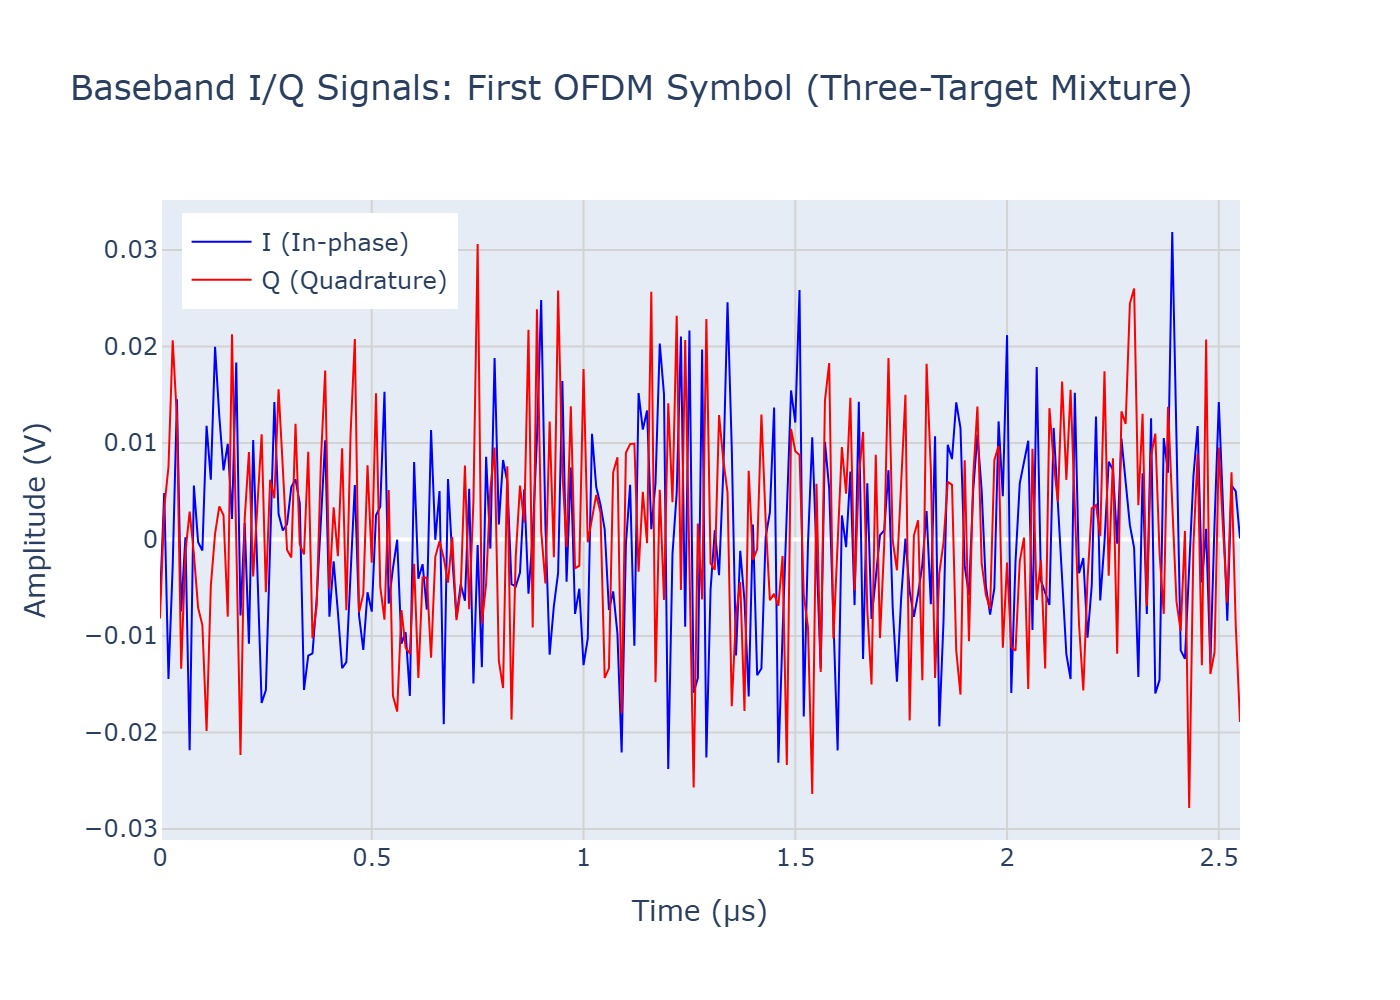

In [44]:
# Create figure for baseband visualization
fig = go.Figure()

# Plot In-phase (I) component of first OFDM symbol
fig.add_trace(
    go.Scatter(
        x=timestamp[0, 0, :] * 1e6,
        y=np.real(baseband[0, 0, :]),
        name="I (In-phase)",
        line=dict(color="blue", width=1),
    )
)

# Plot Quadrature (Q) component of first OFDM symbol
fig.add_trace(
    go.Scatter(
        x=timestamp[0, 0, :] * 1e6,
        y=np.imag(baseband[0, 0, :]),
        name="Q (Quadrature)",
        line=dict(color="red", width=1),
    )
)

fig.update_layout(
    title="Baseband I/Q Signals: First OFDM Symbol (Three-Target Mixture)",
    yaxis=dict(title="Amplitude (V)", gridcolor="lightgray"),
    xaxis=dict(title="Time (μs)", gridcolor="lightgray"),
    height=500,
    legend=dict(x=0.02, y=0.98),
)

show(fig)

## OFDM Radar Signal Processing

### Per-Symbol Range Processing (Data Removal + IFFT)

For every received OFDM symbol:

1. **FFT** the time-domain samples back to subcarrier symbols: $Y_k = \text{FFT}\{y(t)\}$
2. **Remove the known data** by dividing by the transmitted QPSK symbols: $H_k = Y_k / X_k$ — this cancels the communication content and leaves only the channel's range-dependent phase ramp
3. **IFFT** across subcarriers converts the phase ramp into a range profile, with a peak at each target's delay

Result: range profile matrix `[1 channel, 256 symbols, 256 range bins]`, with 1.5 m range resolution (same as the FMCW example, since both use 100 MHz of bandwidth).

In [45]:
# Initialize range profile storage: [1 channel, 256 symbols, 256 range bins]
range_profile = np.zeros((1, n_pulses, N_sc), dtype=complex)

# Per-symbol OFDM range processing
for pulse_idx in range(n_pulses):
    # Step 1: FFT the received time-domain symbol back to subcarrier symbols
    rx_freq = np.fft.fft(baseband[0, pulse_idx, :])

    # Step 2: Remove the known QPSK data -> channel frequency response
    channel_est = rx_freq / data_symbols

    # Step 3: IFFT across subcarriers -> range profile
    range_profile[0, pulse_idx, :] = np.fft.ifft(channel_est)

### Visualize Range Profiles

Display 3D surface showing range profiles across all 256 OFDM symbols.

**Interpretation:**

- **X-axis**: Range (meters) → Target distance
- **Y-axis**: OFDM symbol index (0-255) → Time progression
- **Z-axis**: Amplitude (dB) → Detection strength
- **Peaks**: Target locations at specific ranges

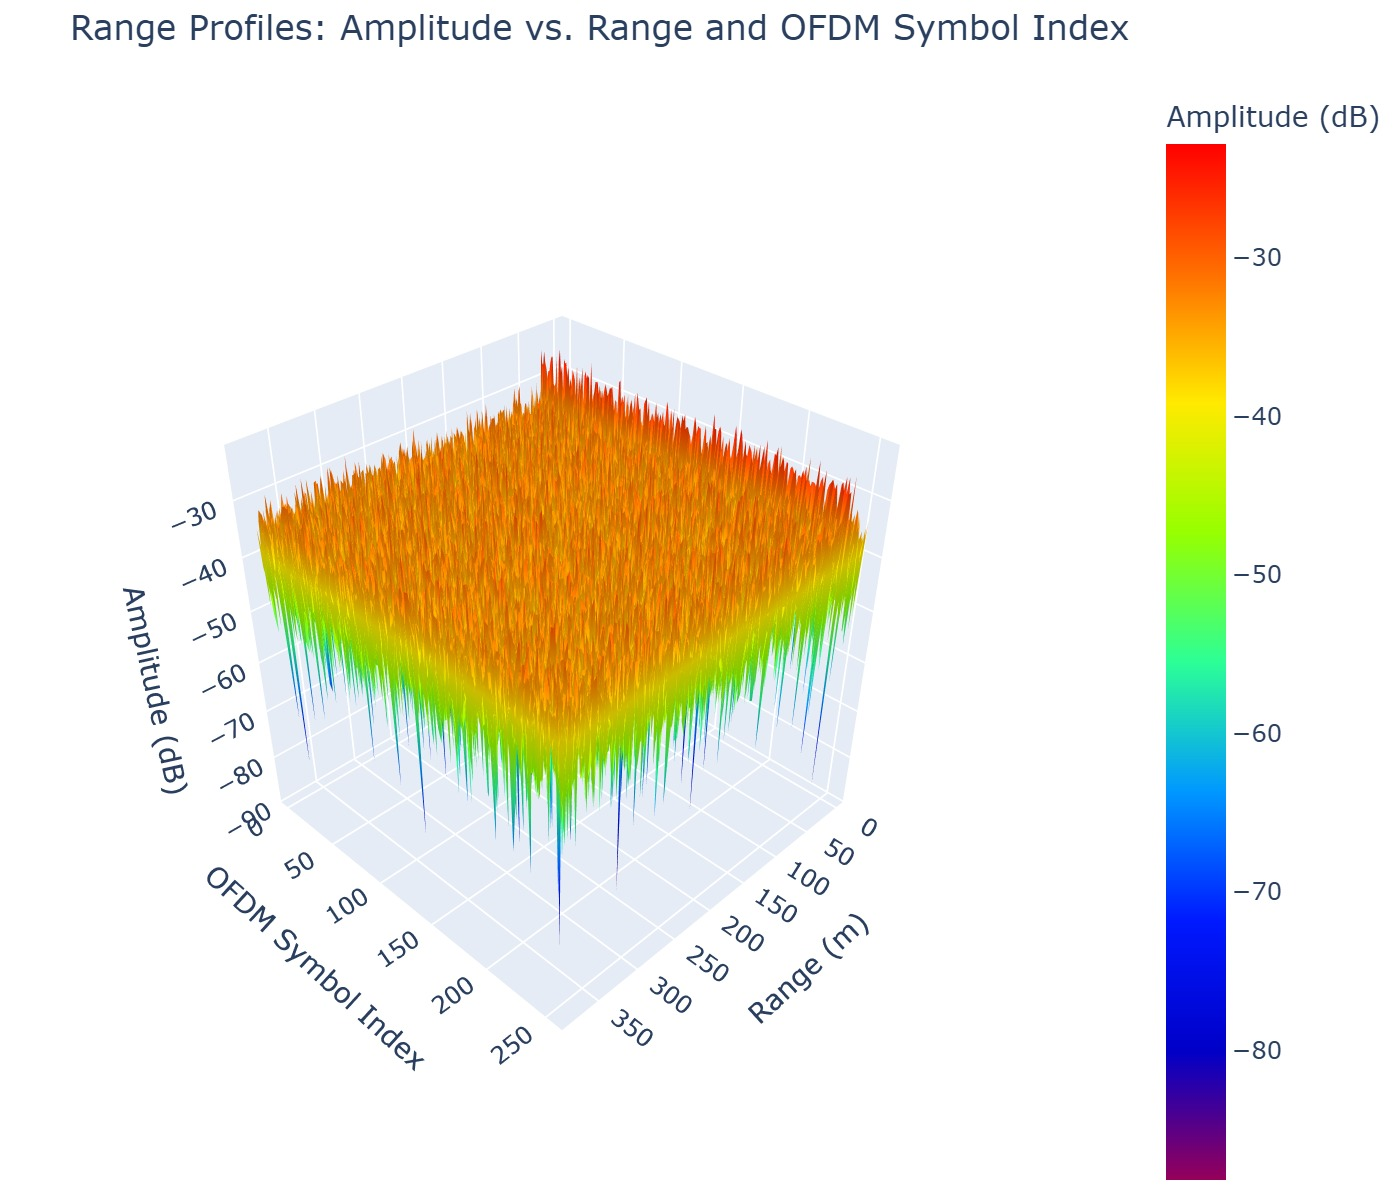

In [46]:
# Range axis: bin index x resolution (c / (2 x bandwidth))
range_axis = np.arange(N_sc) * 3e8 / (2 * bandwidth)
symbol_axis = np.arange(n_pulses)

fig = go.Figure()
fig.add_trace(
    go.Surface(
        x=range_axis,
        y=symbol_axis,
        z=20 * np.log10(np.abs(range_profile[0, :, :])),
        colorscale="Rainbow",
        colorbar=dict(title="Amplitude (dB)"),
    )
)

fig.update_layout(
    title="Range Profiles: Amplitude vs. Range and OFDM Symbol Index",
    height=600,
    scene=dict(
        xaxis=dict(title="Range (m)"),
        yaxis=dict(title="OFDM Symbol Index"),
        zaxis=dict(title="Amplitude (dB)"),
        camera=dict(eye=dict(x=1.8, y=1.8, z=1.8)),
        aspectmode="cube",
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

show(fig)

### Doppler Processing (Slow-Time FFT)

A Chebyshev window (60 dB sidelobe suppression) is applied across the 256 OFDM symbols (slow-time) at each range bin, then an FFT converts symbol-to-symbol phase into Doppler frequency → radial velocity:

$$v = \frac{f_d \cdot c}{2 f_c}$$

Result: Range-Doppler map `[velocity bins × range bins]`.

In [47]:
# Create Chebyshev window for Doppler FFT (60 dB sidelobe suppression)
doppler_window = signal.windows.chebwin(n_pulses, at=60)

# Perform Doppler FFT across OFDM symbols (slow-time) and center zero velocity
range_doppler = np.fft.fftshift(
    np.fft.fft(
        range_profile * doppler_window[np.newaxis, :, np.newaxis],
        axis=1,
    ),
    axes=1,
)

# Maximum unambiguous velocity: v_max = c / (2 * fc * PRP)
prp = radar.radar_prop["transmitter"].waveform_prop["prp"][0]
unambiguous_speed = 3e8 / prp / fc / 2

### Visualize Range-Doppler Map

**Interpretation:**

- **X-axis**: Range (m) → Target distance
- **Y-axis**: Velocity (m/s) → Radial velocity (negative = approaching)
- **Z-axis**: Amplitude (dB) → Detection strength
- **Peaks**: Three targets at their (range, velocity) coordinates: (120 m, −5 m/s), (70 m, −50 m/s), (30 m, −22 m/s)

Note the coarse velocity resolution ($\Delta v = v_{max}/256 \approx 9.5$ m/s) — a direct consequence of the very short 2.56 μs PRP that gives OFDM its huge unambiguous velocity range. See "Things to Try" below for how to trade this off.

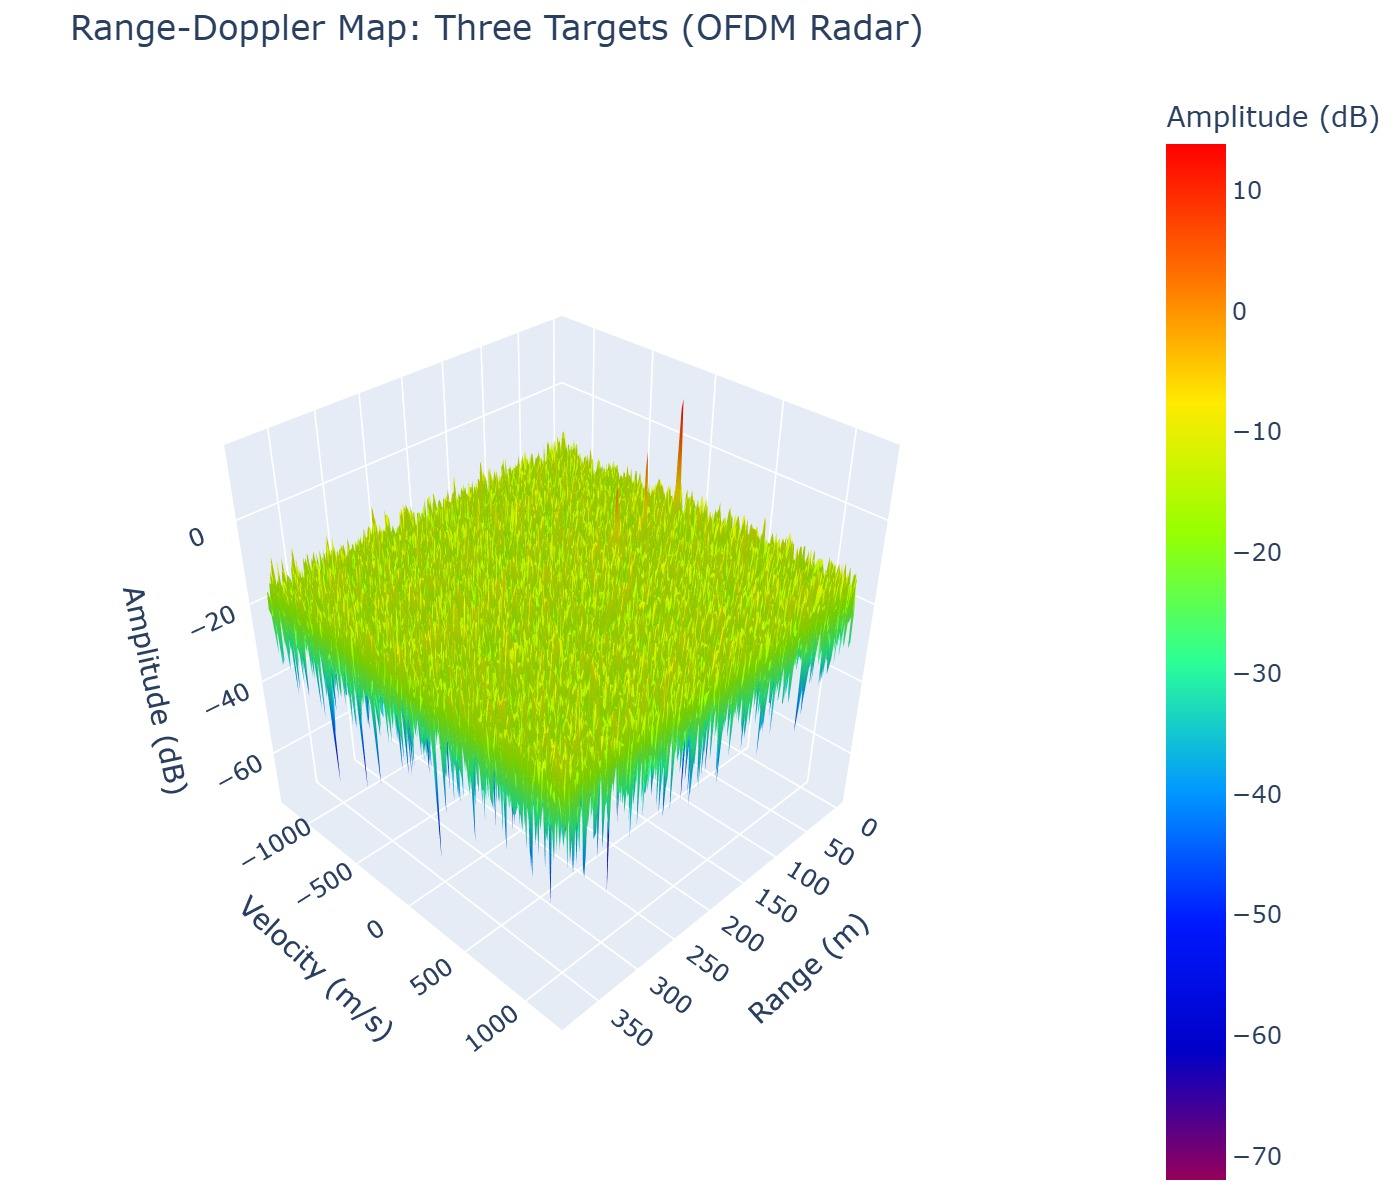

In [52]:
# Velocity axis centered around zero
doppler_axis = np.linspace(
    -unambiguous_speed / 2,
    unambiguous_speed / 2,
    n_pulses,
    endpoint=False,
)

fig = go.Figure()
fig.add_trace(
    go.Surface(
        x=range_axis,
        y=doppler_axis,
        z=20 * np.log10(np.abs(range_doppler[0, :, :])),
        colorscale="Rainbow",
        colorbar=dict(title="Amplitude (dB)"),
    )
)

fig.update_layout(
    title="Range-Doppler Map: Three Targets (OFDM Radar)",
    height=600,
    scene=dict(
        xaxis=dict(title="Range (m)"),
        yaxis=dict(title="Velocity (m/s)"),
        zaxis=dict(title="Amplitude (dB)"),
        aspectmode="cube",
        camera=dict(eye=dict(x=1.8, y=1.8, z=1.8)),
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

show(fig)

## Summary

This notebook demonstrated a complete OFDM radar simulation and range-Doppler processing chain:

- **Random QPSK data** on 256 subcarriers is converted to a time-domain waveform via **IFFT**, exactly as in an OFDM communication transmitter.
- **Range** is recovered per OFDM symbol by dividing the received subcarrier spectrum by the known transmitted data (removing the communication content) and taking an **IFFT** — analogous to matched filtering in PMCW.
- **Velocity** is recovered the same way as FMCW/PMCW: a windowed FFT across symbols (slow-time).
- Using the same 100 MHz bandwidth as the FMCW example gives the same 1.5 m range resolution, while the short 2.56 μs symbol duration gives a very high unambiguous velocity (~2.4 km/s) with no aliasing for any of the three targets.
- OFDM's wide instantaneous (noise) bandwidth makes its link budget more demanding than FMCW's narrowband beat-frequency approach, so higher TX power and/or a more balanced RCS-vs-range spread across targets is needed to keep every target visible above the range/Doppler sidelobes of the strongest one.
- Unlike FMCW and PMCW, the OFDM waveform inherently carries a data payload — the same signal used for ranging could simultaneously carry a communication link (joint radar-communication).

### Things to Try

| Experiment | Parameter to change | Observable effect |
|------------|--------------------|--------------------|
| Better range resolution | Increase `N_sc` (keep `df` fixed) | More bandwidth → sharper range peaks |
| Better velocity resolution | Increase `n_pulses`, or increase `PRP` via a guard interval | Finer Doppler bins, at the cost of $v_{max}$ |
| Higher-order modulation | Switch QPSK to 16-QAM | Same ranging principle, more data throughput |
| Randomize data per symbol | Generate new `data_symbols` every pulse | More realistic comms-radar co-design; requires per-symbol demod reference |
| Cyclic prefix | Prepend a copy of the symbol tail | Robustness to multipath / longer max range without ambiguity |
| Weaker target detection | Reduce `rcs` | Peak amplitude drops; noise floor visible |
| MIMO OFDM | Add a second TX channel/subcarrier set | Compare with the PMCW MIMO example |